# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [41]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

#from advertising_market_simulator import AdvertisementMarketSimulator
from environment.environment import Environment
from experiment import Experiment
from campaigns.slightly_non_stationary_campaign import SlightlyNonStationaryCampaign
from bidders.UCB_based.sliding_window_combinatorial_ucb_like_bidder import SlidingWindowCombinatorialUCBLikeBidder
from bidders.UCB_based.cusum_combinatorial_ucb_like_bidder import CUSUMCombinatorialUCBLikeBidder
from bidders.primal_dual.primal_dual_bidder import PrimalDualBidder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Requirement 4: Slightly non-stationary environments with multiple campaigns

### Non-stationary environment

Build a slightly non-stationary environment for the pricing problem. At a high level:
- Rounds are partitioned in intervals
- In each interval the distribution of highest competing bids is fixed
- Each interval has a different distribution

Modeling assumptions: A slight non-stationarity can come from the bids intrinsically changing due to a number of reasons, i.e. because budgets get depleted or reset by the competitors, or for individual adaptation of the competitors' learning algorithms. Also, the correlation between campaigns is slightly non-stationary too. For example: during holidays of events such as Black Friday, people are likely to spend more, so it is more important to secure a slot for your own product (practically, because of higher q, I guess).

In [42]:
N_TRIALS = 2  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

# market = AdvertisementMarketSimulator()
environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=3, campaign_type=SlightlyNonStationaryCampaign, min_competitors=3, max_competitors=5, conflicts_percentage=0.4, seed=47)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 1000  # number of ads to be shown sequentially = n_rounds = T

RHO = 0.15  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 3
Campaigns:
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    Number of phases: 5
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
    Number of phases: 2
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
    Number of phase

### Algorithm

Extend the Combinatorial-UCB approach in Requirement 2 with:
- sliding window
- a change detector

### Compare

Compare the performance of:
- Combinatorial-UCB with sliding window
- Combinatorial-UCB with the change detector
- The primal-dual method

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([  0, 173, 544, 841, 956]), array([  0, 396]), array([  0, 285, 405, 686, 753])]
joined_phase_change_times: [  0 173 285 396 405 544 686 753 841 956]
joined_indices: [array([0, 1, 1, 1, 1, 2, 2, 2, 3, 4], dtype=int64), array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=int64), array([0, 0, 1, 1, 2, 2, 3, 4, 4, 4], dtype=int64)]
campaign_gamma_values: [array([[0.        , 0.        , 0.        , 0.        , 0.51549001,
        0.48450999, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.27859662, 0.72140338,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.86250402,
        0.13749598, 0.        , 0.        ],
       [0.27703012, 0.72296988, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.89062945, 0.10937055,
        0.        , 0.        , 0.   

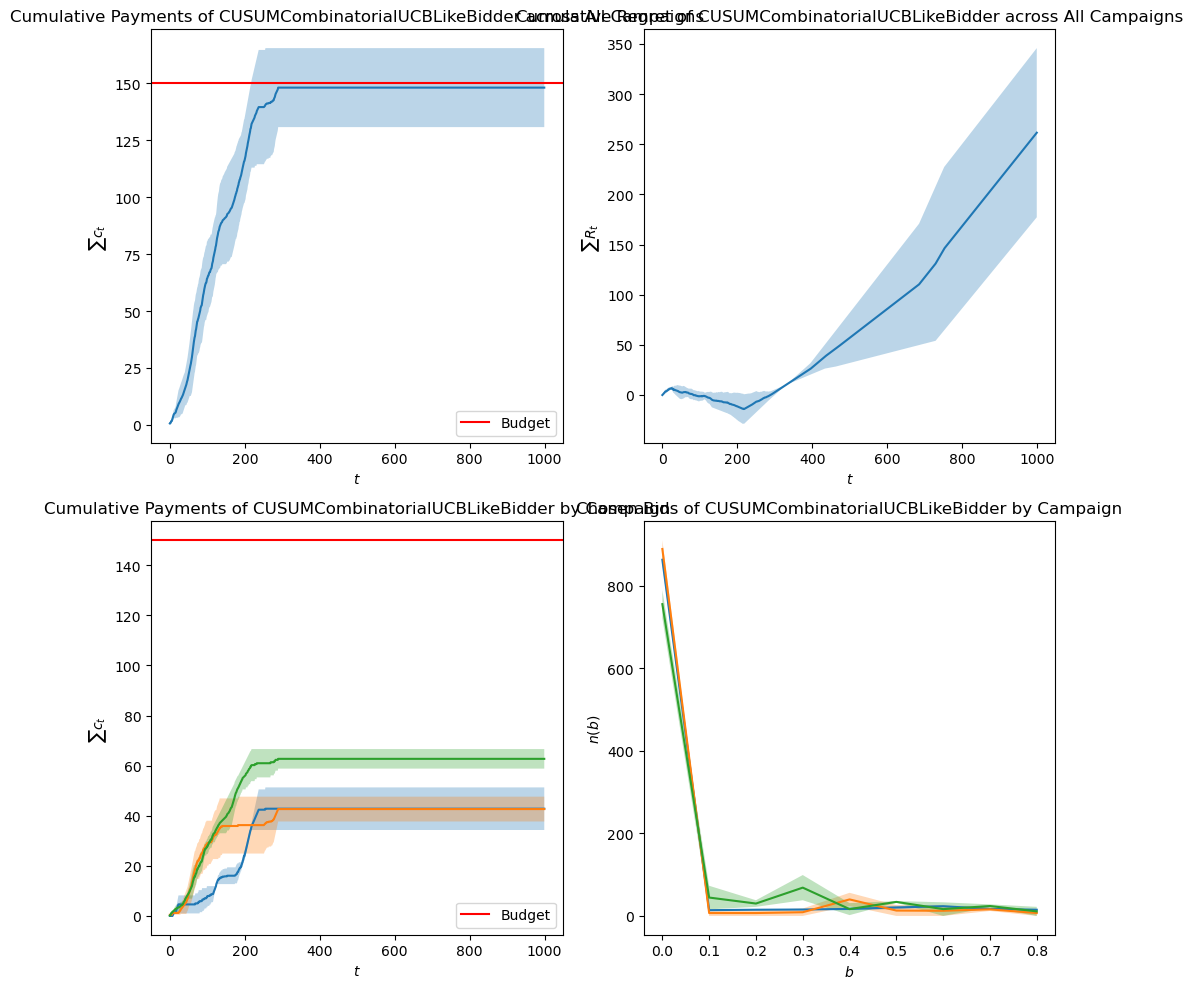

In [43]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

M = 50              # number of samples to be collected in estimation phase of an arm to initialize CUSUM (not too many, or estimation is going to take too long!)
EPS = 0.05          # how much we expect a single reward to deviate from the mean, this acts like a "dampening" factor that prevents estimated std building up from too quickly, limits the rate of "false positives"
                    # this also signals the minimum change in mean that we consider significant in practice, since a change of 0.0000001 would not really be relevant...
                    # TODO: I think relating this to the spacing between bids might actually be a good idea)
H = 2               # cumulate estimated std that signals a change in behavior, this too limits the rate of "false positives" -> larger = fewer "false alarms", but slower detection
ALPHA = 0.05        # exploration probability

budget_constrained_multiple_campaigns_CUSUM_combinatorial_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=CUSUMCombinatorialUCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment,
                                                              'M': M,
                                                              'eps': EPS,
                                                              'h': H,
                                                              'alpha': ALPHA
                                                            })

budget_constrained_multiple_campaigns_CUSUM_combinatorial_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simple')

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([  0, 173, 544, 841, 956]), array([  0, 396]), array([  0, 285, 405, 686, 753])]
joined_phase_change_times: [  0 173 285 396 405 544 686 753 841 956]
joined_indices: [array([0, 1, 1, 1, 1, 2, 2, 2, 3, 4], dtype=int64), array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=int64), array([0, 0, 1, 1, 2, 2, 3, 4, 4, 4], dtype=int64)]
campaign_gamma_values: [array([[0.        , 0.        , 0.        , 0.        , 0.51549001,
        0.48450999, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.27859662, 0.72140338,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.86250402,
        0.13749598, 0.        , 0.        ],
       [0.27703012, 0.72296988, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.89062945, 0.10937055,
        0.        , 0.        , 0.   

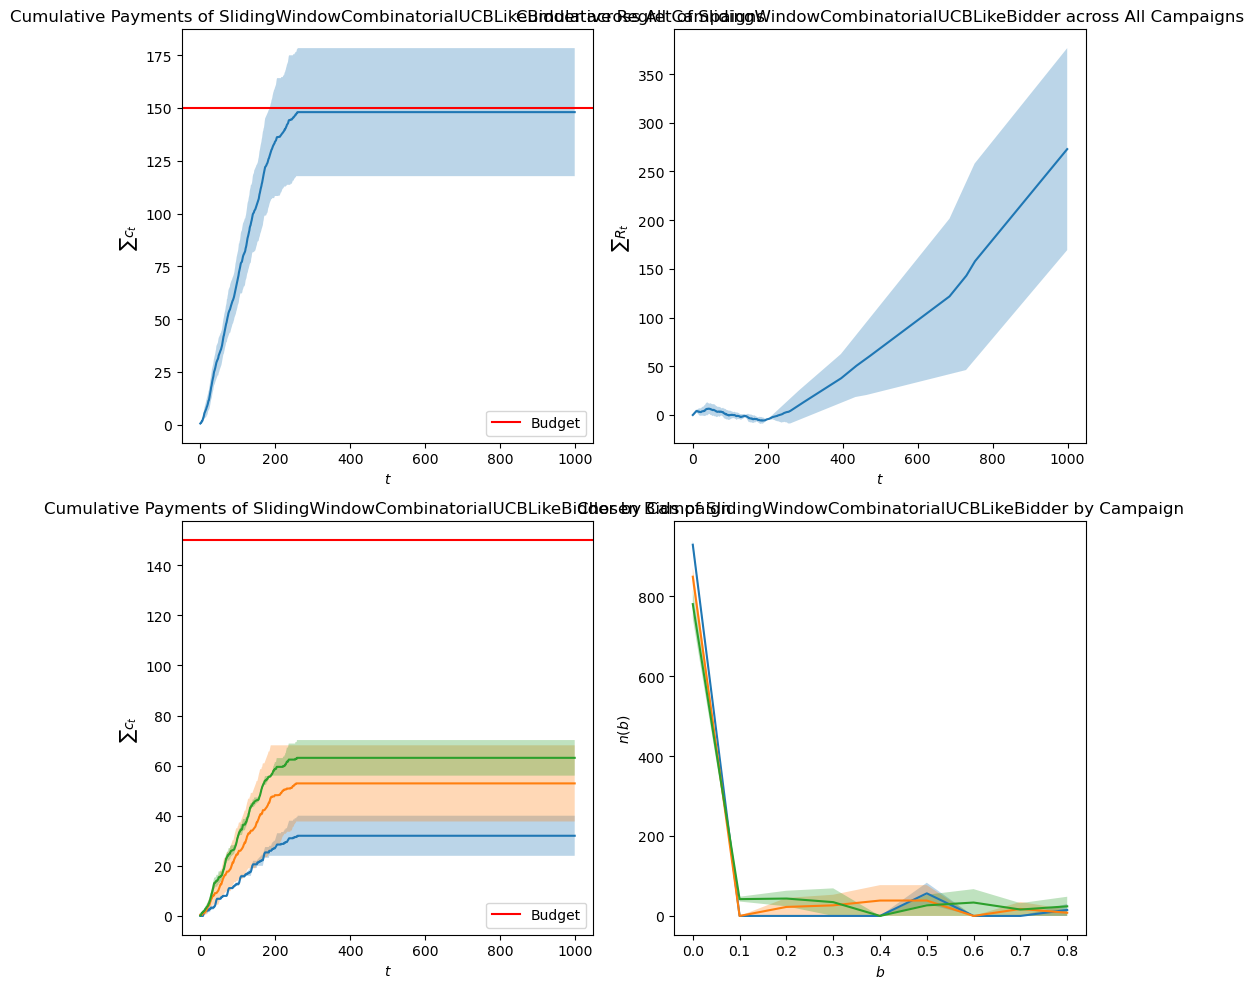

In [44]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

WINDOW_SIZE = np.sqrt(N_USERS)  # window size for the sliding window UCB-like bidder = T log T / T

budget_constrained_multiple_campaigns_sliding_window_combinatorial_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=SlidingWindowCombinatorialUCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment,
                                                              'window_size': WINDOW_SIZE,
                                                            })

budget_constrained_multiple_campaigns_sliding_window_combinatorial_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simple')

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([  0, 173, 544, 841, 956]), array([  0, 396]), array([  0, 285, 405, 686, 753])]
joined_phase_change_times: [  0 173 285 396 405 544 686 753 841 956]
joined_indices: [array([0, 1, 1, 1, 1, 2, 2, 2, 3, 4], dtype=int64), array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=int64), array([0, 0, 1, 1, 2, 2, 3, 4, 4, 4], dtype=int64)]
campaign_gamma_values: [array([[0.        , 0.        , 0.        , 0.        , 0.51549001,
        0.48450999, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.27859662, 0.72140338,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.86250402,
        0.13749598, 0.        , 0.        ],
       [0.27703012, 0.72296988, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.89062945, 0.10937055,
        0.        , 0.        , 0.   

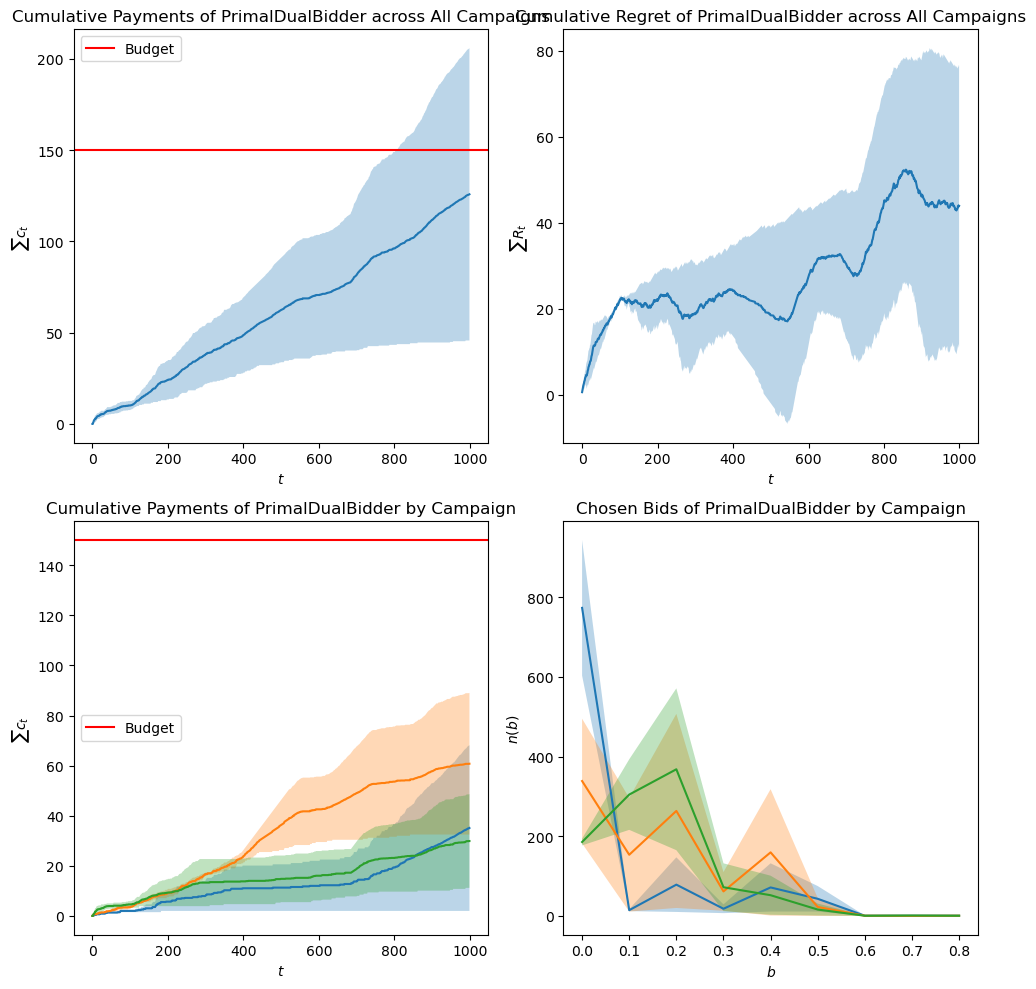

In [45]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

LEARNING_RATE_PRIMAL = 1
LEARNING_RATE_DUAL = 1

budget_constrained_multiple_campaigns_primal_dual_experiment = Experiment(environment=environment,
                                                          bidder_class=PrimalDualBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment,
                                                              'learning_rate_primal': LEARNING_RATE_PRIMAL,
                                                              'learning_rate_dual': LEARNING_RATE_DUAL
                                                            })

budget_constrained_multiple_campaigns_primal_dual_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simple')